In [ ]:
import json
from pathlib import Path
import pickle as pkl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

dirpath_base = Path().resolve().parent

dirname = 'samn'
#dirname = 'ouinp'
with open(dirpath_base / 'revision' / dirname / 'cfg.json', 'r') as fid:
    cfg = json.load(fid)
wmat = cfg['simConfig']['wmat']

with open(dirpath_base / 'revision' / dirname / 'conn.pkl', 'rb') as fid:
    conn = pkl.load(fid)
pmat = conn['pmat']

In [22]:
Epops = ['IT2', 'IT3', 'ITP4', 'ITS4', 'IT5A', 'CT5A', 'IT5B', 'CT5B' , 'PT5B', 'IT6', 'CT6']  # all layers

Ipops = ['NGF1',                            # L1
        'PV2', 'SOM2', 'VIP2', 'NGF2',      # L2
        'PV3', 'SOM3', 'VIP3', 'NGF3',      # L3
        'PV4', 'SOM4', 'VIP4', 'NGF4',      # L4
        'PV5A', 'SOM5A', 'VIP5A', 'NGF5A',  # L5A  
        'PV5B', 'SOM5B', 'VIP5B', 'NGF5B',  # L5B
        'PV6', 'SOM6', 'VIP6', 'NGF6']      # L6

Itypes = ['PV', 'SOM', 'VIP', 'NGF']
Etypes = {'2': ['IT'], '3': ['IT'], '4': ['ITP', 'ITS'], 
          '5A': ['IT', 'CT'], '5B': ['IT', 'CT', 'PT'], '6': ['IT', 'CT']}
#Etypes = {'2': ['IT'], '3': ['IT'], '4': ['ITP'], 
#          '5A': ['IT'], '5B': ['IT'], '6': ['IT']}

pops = []
for l in ['2', '3', '4', '5A', '5B', '6']:
#for l in ['3', '4', '5A', '6']:
    for et in Etypes[l]:
        pops += [et + l]
    for it in Itypes:
        pops += [it + l]
print(pops)

['IT2', 'PV2', 'SOM2', 'VIP2', 'NGF2', 'IT3', 'PV3', 'SOM3', 'VIP3', 'NGF3', 'ITP4', 'ITS4', 'PV4', 'SOM4', 'VIP4', 'NGF4', 'IT5A', 'CT5A', 'PV5A', 'SOM5A', 'VIP5A', 'NGF5A', 'IT5B', 'CT5B', 'PT5B', 'PV5B', 'SOM5B', 'VIP5B', 'NGF5B', 'IT6', 'CT6', 'PV6', 'SOM6', 'VIP6', 'NGF6']


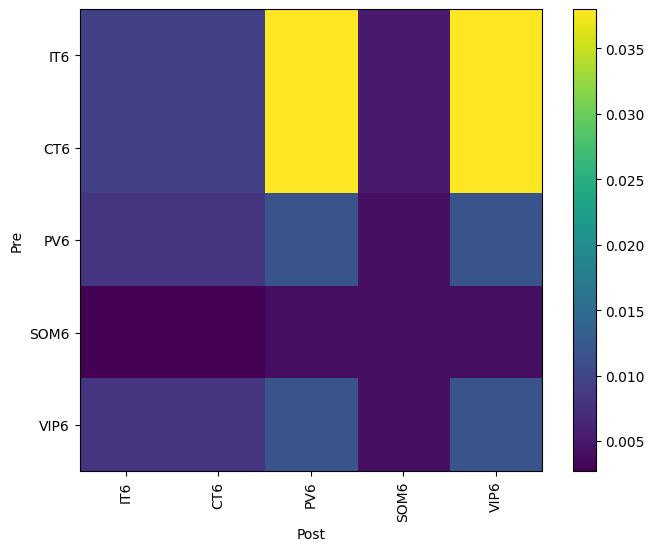

In [ ]:
#pops = ['ITP4', 'ITS4', 'PV4', 'SOM4', 'VIP4']
#pops = ['IT3', 'PV3', 'SOM3', 'VIP3']
#pops = ['IT2', 'PV2', 'SOM2', 'VIP2']
#pops = ['IT6', 'CT6', 'PV6', 'SOM6', 'VIP6']

""" pops = ['IT2', 'IT3', 'ITS4', 'ITP4', 'IT5A', 'CT5A', 
        'IT5B', 'CT5B', 'PT5B', 'IT6', 'CT6',
        'TC', 'HTC', 'TCM'
        #'TI', 'TIM', 'IRE', 'IREM'
        ] """

#pops = list(pmat.keys())

C = xr.DataArray(np.zeros((len(pops), len(pops))),
                 coords=[pops, pops], dims=['pre', 'post'])
W = C.copy()
for pre in pops:
    for post in pops:
        if (pre in pmat) and (post in pmat[pre]):
            C.loc[pre, post] = pmat[pre][post]
        if (pre in wmat) and (post in wmat[pre]):
            W.loc[pre, post] = wmat[pre][post]

plt.figure(figsize=(8, 6))
ax = plt.gca()
#im = ax.imshow(C, cmap='viridis')
#im = ax.imshow(np.log(C), cmap='viridis', origin='upper')
im = ax.imshow(W, cmap='viridis')

# Add colorbar
plt.colorbar(im, ax=ax)

# Set tick labels
ax.set_xticks(np.arange(len(pops)))
ax.set_yticks(np.arange(len(pops)))
ax.set_xticklabels(pops, rotation=90)
ax.set_yticklabels(pops)

# Add labels
ax.set_xlabel('Post')
ax.set_ylabel('Pre')

#plt.title('Connection probability (log)')
plt.show()


In [19]:
#pops.pop(pops.index('TC'))
print(pops)

['IT2', 'IT3', 'ITS4', 'ITP4', 'IT5A', 'CT5A', 'IT5B', 'CT5B', 'PT5B', 'IT6', 'CT6', 'TC', 'HTC', 'TCM']
